In [ ]:
#결측치 = Missing Value 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from fancyimpute import IterativeImputer
from sklearn.metrics import mean_squared_error

In [3]:
np.random.seed(1)
data =np.random.normal(10,2,100)

In [4]:
df_fin=pd.DataFrame(data, columns=['feature'])

In [5]:
## missing 만들기
df_missing=df_fin.copy()

In [6]:
#결측치생성 
df_missing.loc[5:10, 'feature'] =np.nan
df_missing.loc[30:35, 'feature'] =np.nan
df_missing.loc[40:55, 'feature'] =np.nan

In [8]:
## 선형보간,가장 기본적인 보간 방법
df_linear=df_missing.interpolate(method='linear')
## quadratic,이차보간 : 데이터의 비선형적 추세를 더 잘 반영함
df_quadratic=df_missing.interpolate(method='quadratic')
## 평균
df_mean = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(df_missing), columns=['feature'])
## 0 : 결측값이 존재하지 않음을 의미
df_zero = df_missing.fillna(0)
## KNN : 결측값을 포함하지 않는 행들간의 유사성을 기반
df_knn =pd.DataFrame(KNNImputer(n_neighbors=3).fit_transform(df_missing), columns =['feature'])
## MICE : 가장 정교하고 정확한 대체 기법 
df_mice =pd.DataFrame(IterativeImputer(random_state=111).fit_transform(df_missing), columns =['feature'])

Text(0.5, 1.0, 'Mice Imputation')

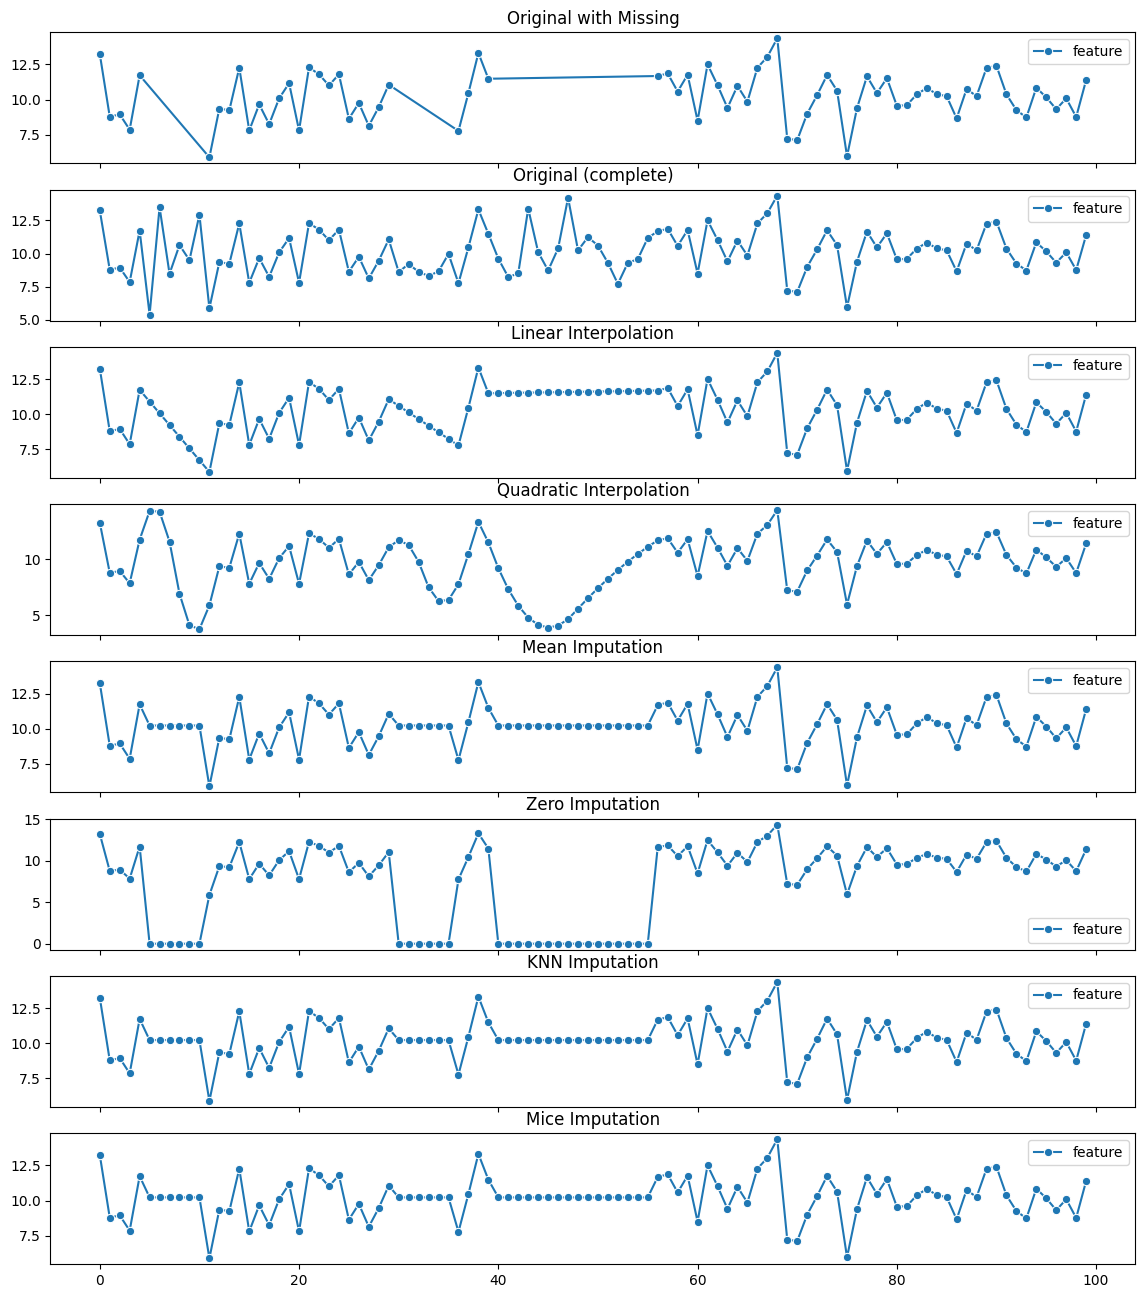

In [9]:

fig, axs =plt.subplots(8,1, figsize=(14,16), sharex=True)

sns.lineplot(data= df_missing, marker='o', ax=axs[0], color='gray')
axs[0].set_title('Original with Missing')

sns.lineplot(data= df_fin, marker='o', ax=axs[1], color='black')
axs[1].set_title('Original (complete)')

sns.lineplot(data= df_linear, marker='o', ax=axs[2], color='black')
axs[2].set_title('Linear Interpolation')

sns.lineplot(data= df_quadratic, marker='o', ax=axs[3], color='black')
axs[3].set_title('Quadratic Interpolation')

sns.lineplot(data= df_mean, marker='o', ax=axs[4], color='black')
axs[4].set_title('Mean Imputation')

sns.lineplot(data= df_zero, marker='o', ax=axs[5], color='black')
axs[5].set_title('Zero Imputation')

sns.lineplot(data= df_knn, marker='o', ax=axs[6], color='black')
axs[6].set_title('KNN Imputation')

sns.lineplot(data= df_mice, marker='o', ax=axs[7], color='black')
axs[7].set_title('Mice Imputation')

In [10]:
##성능비교를 위해 결측치 위치 비교 
missing_idx=df_missing[df_missing['feature'].isnull()].index

res = {
    'Linear' :mean_squared_error(df_fin.loc[missing_idx], df_linear.loc[missing_idx]),
    'Quadratic' :mean_squared_error(df_fin.loc[missing_idx], df_quadratic.loc[missing_idx]),    
    'Mean' :mean_squared_error(df_fin.loc[missing_idx], df_mean.loc[missing_idx]),
    'Zero' :mean_squared_error(df_fin.loc[missing_idx], df_zero.loc[missing_idx]),
    'KNN' :mean_squared_error(df_fin.loc[missing_idx], df_knn.loc[missing_idx]),
    'MICE' :mean_squared_error(df_fin.loc[missing_idx], df_mice.loc[missing_idx]),
}

res_df=pd.DataFrame.from_dict(res, orient = 'index', columns =['MSE']).sort_values('MSE')


In [11]:
res_df

,MSE
Mean,3.686203
KNN,3.686203
MICE,3.686203
Linear,6.372685
Quadratic,20.721454
Zero,100.790670


In [12]:
df_fin.describe()

,feature
count,100.000000
mean,10.121166
std,1.779231
min,5.396923
25%,8.772365
50%,10.128148
75%,11.274821
max,14.371151


(array([ 3.,  1.,  6., 17., 19., 20., 14., 12.,  5.,  3.]),
 array([ 5.39692261,  6.29434543,  7.19176825,  8.08919107,  8.98661389,
         9.88403671, 10.78145953, 11.67888235, 12.57630517, 13.47372799,
        14.37115081]),
 <BarContainer object of 10 artists>)

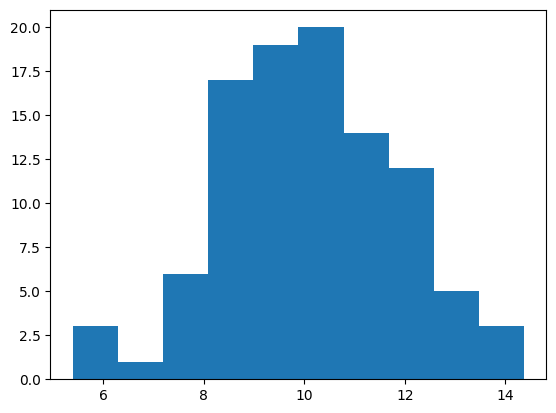

In [13]:
plt.hist(df_fin)